In [6]:
!pip install torch torchvision matplotlib --quiet

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import os

In [8]:
!wget http://efrosgans.eecs.berkeley.edu/pix2pix/datasets/facades.tar.gz
!tar -xvf facades.tar.gz

--2026-02-26 16:23:33--  http://efrosgans.eecs.berkeley.edu/pix2pix/datasets/facades.tar.gz
Resolving efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)... 128.32.244.190
Connecting to efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)|128.32.244.190|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 30168306 (29M) [application/x-gzip]
Saving to: ‘facades.tar.gz’

facades.tar.gz      100%[===================>]  28.77M  3.83MB/s    in 8.9s    

2026-02-26 16:23:42 (3.25 MB/s) - ‘facades.tar.gz’ saved [30168306/30168306]

facades/
facades/test/
facades/test/27.jpg
facades/test/5.jpg
facades/test/72.jpg
facades/test/1.jpg
facades/test/10.jpg
facades/test/100.jpg
facades/test/101.jpg
facades/test/102.jpg
facades/test/103.jpg
facades/test/104.jpg
facades/test/105.jpg
facades/test/106.jpg
facades/test/11.jpg
facades/test/12.jpg
facades/test/13.jpg
facades/test/14.jpg
facades/test/15.jpg
facades/test/16.jpg
facades/test/17.jpg
facades/test/18.jpg
facades/te

In [9]:
class Pix2PixDataset(torch.utils.data.Dataset):
    def __init__(self, root_dir, transform=None, limit=200):
        self.root_dir = root_dir
        self.images = os.listdir(root_dir)[:limit]   # LIMIT FOR FAST TRAINING
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = plt.imread(os.path.join(self.root_dir, self.images[idx]))

        w = img.shape[1]
        input_img = img[:, :w//2]     # facade label
        target_img = img[:, w//2:]    # real building

        input_img = self.transform(input_img)
        target_img = self.transform(target_img)

        return input_img, target_img

In [10]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((256,256)),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = Pix2PixDataset("facades/train", transform)
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)

In [11]:
class UNetGenerator(nn.Module):
    def __init__(self):
        super().__init__()

        def down(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c,out_c,4,2,1),
                nn.BatchNorm2d(out_c),
                nn.LeakyReLU(0.2)
            )

        def up(in_c, out_c):
            return nn.Sequential(
                nn.ConvTranspose2d(in_c,out_c,4,2,1),
                nn.BatchNorm2d(out_c),
                nn.ReLU()
            )

        self.d1 = down(3,64)
        self.d2 = down(64,128)
        self.d3 = down(128,256)

        self.u1 = up(256,128)
        self.u2 = up(256,64)
        self.u3 = nn.ConvTranspose2d(128,3,4,2,1)

        self.tanh = nn.Tanh()

    def forward(self,x):
        d1 = self.d1(x)
        d2 = self.d2(d1)
        d3 = self.d3(d2)

        u1 = self.u1(d3)
        u1 = torch.cat([u1,d2],1)

        u2 = self.u2(u1)
        u2 = torch.cat([u2,d1],1)

        return self.tanh(self.u3(u2))

In [12]:
class PatchGAN(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(6,64,4,2,1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64,128,4,2,1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Conv2d(128,256,4,2,1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),

            nn.Conv2d(256,1,4,1,1)
        )

    def forward(self,x,y):
        return self.model(torch.cat([x,y],1))

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

G = UNetGenerator().to(device)
D = PatchGAN().to(device)

criterion_GAN = nn.BCEWithLogitsLoss()
criterion_L1 = nn.L1Loss()

opt_G = optim.Adam(G.parameters(), lr=0.0002)
opt_D = optim.Adam(D.parameters(), lr=0.0002)

In [14]:
epochs = 5   # FAST TRAINING

for epoch in range(epochs):
    for input_img, target_img in train_loader:

        input_img, target_img = input_img.to(device), target_img.to(device)

        # --- Train D ---
        fake_img = G(input_img)
        D_real = D(input_img, target_img)
        D_fake = D(input_img, fake_img.detach())

        loss_D = (criterion_GAN(D_real, torch.ones_like(D_real)) +
                  criterion_GAN(D_fake, torch.zeros_like(D_fake))) / 2

        opt_D.zero_grad(); loss_D.backward(); opt_D.step()

        # --- Train G ---
        D_fake = D(input_img, fake_img)
        loss_G = criterion_GAN(D_fake, torch.ones_like(D_fake)) + \
                 criterion_L1(fake_img, target_img) * 100

        opt_G.zero_grad(); loss_G.backward(); opt_G.step()

    print(f"Epoch {epoch+1}  Loss D:{loss_D.item():.3f}  Loss G:{loss_G.item():.3f}")

/usr/local/lib/python3.12/dist-packages/torchvision/transforms/functional.py:154: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  img = torch.from_numpy(pic.transpose((2, 0, 1))).contiguous()


Epoch 1  Loss D:0.196  Loss G:48.878
Epoch 2  Loss D:0.076  Loss G:45.748
Epoch 3  Loss D:0.127  Loss G:48.884
Epoch 4  Loss D:0.045  Loss G:50.856
Epoch 5  Loss D:0.380  Loss G:37.326


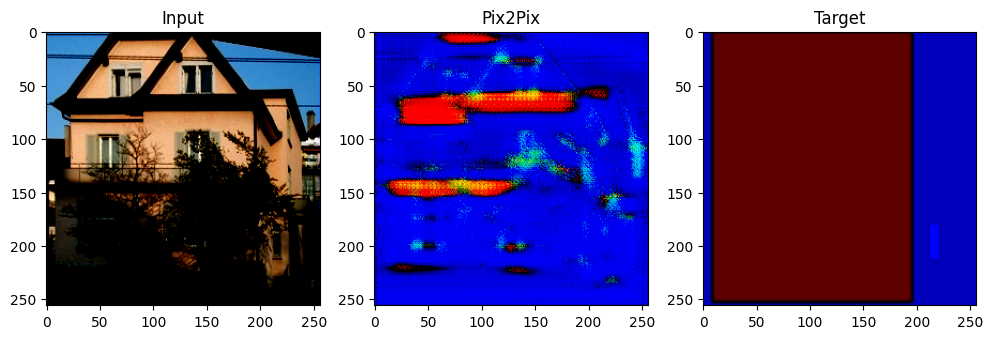

In [15]:
input_img, target_img = next(iter(train_loader))
input_img = input_img.to(device)

with torch.no_grad():
    fake_img = G(input_img)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1); plt.title("Input"); plt.imshow(input_img[0].cpu().permute(1,2,0))
plt.subplot(1,3,2); plt.title("Pix2Pix"); plt.imshow(fake_img[0].cpu().permute(1,2,0))
plt.subplot(1,3,3); plt.title("Target"); plt.imshow(target_img[0].permute(1,2,0))
plt.show()

In [16]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3,64,4,2,1), nn.ReLU(),
            nn.Conv2d(64,128,4,2,1), nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128,64,4,2,1), nn.ReLU(),
            nn.ConvTranspose2d(64,3,4,2,1), nn.Tanh()
        )
    def forward(self,x):
        return self.decoder(self.encoder(x))

In [17]:
cnn = SimpleCNN().to(device)
opt = optim.Adam(cnn.parameters(), lr=0.0002)

for epoch in range(3):
    for x,y in train_loader:
        x,y = x.to(device), y.to(device)
        pred = cnn(x)
        loss = criterion_L1(pred,y)
        opt.zero_grad(); loss.backward(); opt.step()
    print("CNN Epoch", epoch+1, "Loss:", loss.item())

CNN Epoch 1 Loss: 0.5136864185333252
CNN Epoch 2 Loss: 0.4711779057979584
CNN Epoch 3 Loss: 0.5091410875320435
